In [ ]:
!pip install -q kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!kaggle datasets download -d stefanogiannini/crema-d-video

cp: cannot stat 'kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1734, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [ ]:
import os
import json


# Move the kaggle.json file to the correct directory
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d stefanogiannini/crema-d-video

Dataset URL: https://www.kaggle.com/datasets/stefanogiannini/crema-d-video
License(s): ODC Attribution License (ODC-By)


In [ ]:
!unzip /content/crema-d-video.zip -d /content/crema-d-video

Streaming output truncated to the last 5000 lines.
  inflating: /content/crema-d-video/1031_DFA_DIS_XX.flv  
  inflating: /content/crema-d-video/1031_DFA_FEA_XX.flv  
  inflating: /content/crema-d-video/1031_DFA_HAP_XX.flv  
  inflating: /content/crema-d-video/1031_DFA_NEU_XX.flv  
  inflating: /content/crema-d-video/1031_DFA_SAD_XX.flv  
  inflating: /content/crema-d-video/1031_IEO_ANG_HI.flv  
  inflating: /content/crema-d-video/1031_IEO_ANG_LO.flv  
  inflating: /content/crema-d-video/1031_IEO_ANG_MD.flv  
  inflating: /content/crema-d-video/1031_IEO_DIS_HI.flv  
  inflating: /content/crema-d-video/1031_IEO_DIS_LO.flv  
  inflating: /content/crema-d-video/1031_IEO_DIS_MD.flv  
  inflating: /content/crema-d-video/1031_IEO_FEA_HI.flv  
  inflating: /content/crema-d-video/1031_IEO_FEA_LO.flv  
  inflating: /content/crema-d-video/1031_IEO_FEA_MD.flv  
  inflating: /content/crema-d-video/1031_IEO_HAP_HI.flv  
  inflating: /content/crema-d-video/1031_IEO_HAP_LO.flv  
  inflating: /content

# Emotion extraction

In [ ]:
import os
import pandas as pd
dataset_path = "/content/crema-d-video"
emotion_mapping = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}
data = []
for filename in os.listdir(dataset_path):
    if filename.endswith(".flv"):
        parts = filename.split("_")
        emotion_code = parts[2]
        emotion_label = emotion_mapping.get(emotion_code, "Unknown")
        data.append({"file_path": os.path.join(dataset_path, filename), "emotion": emotion_label})
df = pd.DataFrame(data)
print(df.head())
df.to_csv("emotion_labels.csv", index=False)

# Audio extraction

In [ ]:
pip install librosa opencv-python numpy pandas tensorflow

In [ ]:
import librosa
import numpy as np
import os
import pandas as pd

dataset_path = "/content/crema-d-video"
def extract_audio_features(file_path, sr=22050):
    y, sr = librosa.load(file_path, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    spectrogram = librosa.amplitude_to_db(librosa.stft(y))
    pitch, _ = librosa.piptrack(y=y, sr=sr)
    energy = librosa.feature.rms(y=y)
    return {
        "mfcc": np.mean(mfcc, axis=1),
        "spectrogram": np.mean(spectrogram, axis=1),
        "pitch": np.mean(pitch, axis=1),
        "energy": np.mean(energy)
    }

audio_features = []
for filename in os.listdir(dataset_path):
    if filename.endswith(".flv"):
        file_path = os.path.join(dataset_path, filename)
        features = extract_audio_features(file_path)
        features["emotion"] = filename.split("_")[2]
        audio_features.append(features)


audio_df = pd.DataFrame(audio_features)
audio_df.to_csv("audio_features.csv", index=False)

# Video feature extraction

In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

--2025-03-30 11:40:49--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-03-30 11:40:49--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  30.7MB/s    in 2.0s    

2025-03-30 11:40:51 (30.7 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [ ]:
import cv2
import dlib

face_detector = dlib.get_frontal_face_detector()
landmark_predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
def extract_video_features(file_path):
    cap = cv2.VideoCapture(file_path)
    features = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_detector(gray)

        for face in faces:
            landmarks = landmark_predictor(gray, face)
            landmark_points = np.array([(p.x, p.y) for p in landmarks.parts()])
            features.append(landmark_points.flatten())

    cap.release()
    return np.mean(features, axis=0) if features else np.zeros(136)
video_features = []
for filename in os.listdir(dataset_path):
    if filename.endswith(".flv"):
        file_path = os.path.join(dataset_path, filename)
        features = extract_video_features(file_path)
        video_features.append({"file": filename, "features": features})
video_df = pd.DataFrame(video_features)
video_df.to_csv("video_features.csv", index=False)

# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
audio_df = pd.read_csv("audio_features.csv")
video_df = pd.read_csv("video_features.csv")
emotion_df = pd.read_csv("emotion_labels.csv")

In [ ]:
df_expanded_video = video_df['features'].str.replace(r'[\[\]]', '', regex=True).str.split(expand=True)
df_expanded_video.columns = [f'features_{i+1}' for i in range(df_expanded_video.shape[1])]
df_expanded_video = df_expanded_video.astype(float)
df_final_video = pd.concat([video_df, df_expanded_video], axis=1)
df_final_video.drop(columns=['features'], inplace=True)
df_final_video.head()

,file,features_1,features_2,features_3,features_4,features_5,features_6,features_7,features_8,features_9,...,features_127,features_128,features_129,features_130,features_131,features_132,features_133,features_134,features_135,features_136
0,1021_DFA_FEA_XX.flv,171.896552,109.712644,172.988506,122.344828,175.321839,134.287356,177.735632,146.517241,181.678161,...,229.413793,151.919540,241.310345,153.298851,229.528736,153.620690,224.793103,154.241379,220.137931,153.954023
1,1013_DFA_DIS_XX.flv,169.176471,135.058824,171.029412,148.911765,174.176471,162.161765,177.558824,175.147059,182.970588,...,234.911765,173.352941,246.264706,176.470588,235.308824,179.264706,228.808824,180.382353,222.235294,179.720588
2,1049_IEO_FEA_LO.flv,179.625000,159.517857,181.750000,176.678571,184.250000,193.125000,187.732143,209.785714,194.714286,...,261.000000,218.000000,271.678571,220.625000,261.125000,221.696429,255.142857,222.071429,249.089286,221.446429
3,1026_TAI_ANG_XX.flv,173.758621,122.390805,175.597701,136.931034,177.275862,151.172414,179.206897,165.459770,183.137931,...,239.804598,168.666667,247.620690,175.000000,239.850575,176.528736,234.459770,177.264368,228.758621,176.517241
4,1049_MTI_SAD_XX.flv,163.784091,155.022727,165.659091,171.943182,167.988636,188.318182,170.602273,204.977273,176.420455,...,241.363636,215.363636,252.306818,218.295455,241.238636,218.090909,235.375000,218.284091,229.522727,217.670455


In [ ]:
df_expanded_audio = audio_df['mfcc'].str.replace(r'[\[\]]', '', regex=True).str.split(expand=True)
df_expanded_audio.columns = [f'mfcc_{i+1}' for i in range(df_expanded_audio.shape[1])]
df_expanded_audio = df_expanded_audio.astype(float)
df1_audio = pd.concat([audio_df, df_expanded_audio], axis=1)
df1_audio.drop(columns=['mfcc'], inplace=True)

df1_audio.head()

,spectrogram,pitch,energy,emotion,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,[-21.609285 -12.638312 -7.9430184 ... -69.4...,[0. 0. 0. ... 0. 0. 0.],0.003206,FEA,-531.03730,114.269485,47.923508,40.073463,17.549198,9.967312,2.918656,2.300086,-3.589716,2.716598,-4.469267,0.714407,-3.318506
1,[-22.048853 -12.557059 -9.300586 ... -54.2927...,[0. 0. 0. ... 0. 0. 0.],0.006573,DIS,-481.89630,119.484890,26.774048,39.475128,14.693622,0.630914,-2.126806,-0.819650,-2.585632,2.306681,-2.889135,-0.455732,-2.836707
2,[-19.42591 -10.131395 -8.814422 ... -59.0166...,[0. 0. 0. ... 0. 0. 0.],0.006217,FEA,-496.41052,126.656720,37.132664,20.833223,9.351664,13.282156,1.496184,-0.832223,-6.023222,7.847426,0.970901,1.189153,-4.001513
3,[-19.982157 -11.260895 -6.5329423 ... -38.7...,[0. 0. 0. ... 0. 0. 0.],0.056528,ANG,-347.62292,99.667160,27.576390,37.361640,-8.914534,-12.182754,-4.291093,-5.359983,-11.608512,3.770417,-3.840221,-6.738462,-1.049645
4,[-19.011242 -10.144663 -9.18754 ... -55.4941...,[0. 0. 0. ... 0. 0. 0.],0.009731,SAD,-479.16367,134.595380,38.822945,25.863500,6.112208,4.076901,1.771060,-3.325724,-10.762156,-1.888051,-3.561281,2.418926,-4.998400


In [ ]:
df_final_audio = df1_audio.drop(columns = ['spectrogram','pitch'])
df_final_audio.head()

,energy,emotion,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,0.003206,FEA,-531.03730,114.269485,47.923508,40.073463,17.549198,9.967312,2.918656,2.300086,-3.589716,2.716598,-4.469267,0.714407,-3.318506
1,0.006573,DIS,-481.89630,119.484890,26.774048,39.475128,14.693622,0.630914,-2.126806,-0.819650,-2.585632,2.306681,-2.889135,-0.455732,-2.836707
2,0.006217,FEA,-496.41052,126.656720,37.132664,20.833223,9.351664,13.282156,1.496184,-0.832223,-6.023222,7.847426,0.970901,1.189153,-4.001513
3,0.056528,ANG,-347.62292,99.667160,27.576390,37.361640,-8.914534,-12.182754,-4.291093,-5.359983,-11.608512,3.770417,-3.840221,-6.738462,-1.049645
4,0.009731,SAD,-479.16367,134.595380,38.822945,25.863500,6.112208,4.076901,1.771060,-3.325724,-10.762156,-1.888051,-3.561281,2.418926,-4.998400


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_final_audio['emotion'] = le.fit_transform(df_final_audio['emotion'])

In [ ]:
df_final_video['emotion'] = df_final_audio['emotion']
df_final_video.head(2)

,file,features_1,features_2,features_3,features_4,features_5,features_6,features_7,features_8,features_9,...,features_128,features_129,features_130,features_131,features_132,features_133,features_134,features_135,features_136,emotion
0,1021_DFA_FEA_XX.flv,171.896552,109.712644,172.988506,122.344828,175.321839,134.287356,177.735632,146.517241,181.678161,...,151.919540,241.310345,153.298851,229.528736,153.620690,224.793103,154.241379,220.137931,153.954023,2
1,1013_DFA_DIS_XX.flv,169.176471,135.058824,171.029412,148.911765,174.176471,162.161765,177.558824,175.147059,182.970588,...,173.352941,246.264706,176.470588,235.308824,179.264706,228.808824,180.382353,222.235294,179.720588,1


In [ ]:
df_final_video = df_final_video.drop(columns = ['file'],axis=1)

# Merging

In [ ]:
merged_df = pd.concat([df_final_audio,df_final_video],axis=1)
merged_df.head()

,energy,emotion,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,features_128,features_129,features_130,features_131,features_132,features_133,features_134,features_135,features_136,emotion
0,0.003206,2,-531.03730,114.269485,47.923508,40.073463,17.549198,9.967312,2.918656,2.300086,...,151.919540,241.310345,153.298851,229.528736,153.620690,224.793103,154.241379,220.137931,153.954023,2
1,0.006573,1,-481.89630,119.484890,26.774048,39.475128,14.693622,0.630914,-2.126806,-0.819650,...,173.352941,246.264706,176.470588,235.308824,179.264706,228.808824,180.382353,222.235294,179.720588,1
2,0.006217,2,-496.41052,126.656720,37.132664,20.833223,9.351664,13.282156,1.496184,-0.832223,...,218.000000,271.678571,220.625000,261.125000,221.696429,255.142857,222.071429,249.089286,221.446429,2
3,0.056528,0,-347.62292,99.667160,27.576390,37.361640,-8.914534,-12.182754,-4.291093,-5.359983,...,168.666667,247.620690,175.000000,239.850575,176.528736,234.459770,177.264368,228.758621,176.517241,0
4,0.009731,5,-479.16367,134.595380,38.822945,25.863500,6.112208,4.076901,1.771060,-3.325724,...,215.363636,252.306818,218.295455,241.238636,218.090909,235.375000,218.284091,229.522727,217.670455,5


In [ ]:
final_df = merged_df.iloc[:,:-1]
final_df.head()

,energy,emotion,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,features_127,features_128,features_129,features_130,features_131,features_132,features_133,features_134,features_135,features_136
0,0.003206,2,-531.03730,114.269485,47.923508,40.073463,17.549198,9.967312,2.918656,2.300086,...,229.413793,151.919540,241.310345,153.298851,229.528736,153.620690,224.793103,154.241379,220.137931,153.954023
1,0.006573,1,-481.89630,119.484890,26.774048,39.475128,14.693622,0.630914,-2.126806,-0.819650,...,234.911765,173.352941,246.264706,176.470588,235.308824,179.264706,228.808824,180.382353,222.235294,179.720588
2,0.006217,2,-496.41052,126.656720,37.132664,20.833223,9.351664,13.282156,1.496184,-0.832223,...,261.000000,218.000000,271.678571,220.625000,261.125000,221.696429,255.142857,222.071429,249.089286,221.446429
3,0.056528,0,-347.62292,99.667160,27.576390,37.361640,-8.914534,-12.182754,-4.291093,-5.359983,...,239.804598,168.666667,247.620690,175.000000,239.850575,176.528736,234.459770,177.264368,228.758621,176.517241
4,0.009731,5,-479.16367,134.595380,38.822945,25.863500,6.112208,4.076901,1.771060,-3.325724,...,241.363636,215.363636,252.306818,218.295455,241.238636,218.090909,235.375000,218.284091,229.522727,217.670455


# Train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_audio = df_final_audio.drop(columns=["emotion"])
y_audio = df_final_audio["emotion"]
X_video = df_final_video.drop(columns=['emotion'])
y_video = df_final_video["emotion"]
X_train_audio, X_temp_audio, y_train_audio, y_temp_audio = train_test_split(X_audio, y_audio, test_size=0.30, random_state=42, stratify=y_audio)
X_val_audio, X_test_audio, y_val_audio, y_test_audio = train_test_split(X_temp_audio, y_temp_audio, test_size=0.50, random_state=42, stratify=y_temp_audio)
X_train_video, X_temp_video, y_train_video, y_temp_video = train_test_split(X_video, y_video, test_size=0.30, random_state=42, stratify=y_video)
X_val_video, X_test_video, y_val_video, y_test_video = train_test_split(X_temp_video, y_temp_video, test_size=0.50, random_state=42, stratify=y_temp_video)

In [ ]:
X = final_df.drop(columns=["emotion"])
y = final_df["emotion"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [ ]:
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

In [ ]:
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

In [ ]:
print(f"Train: {len(train_df)} samples, Validation: {len(val_df)} samples, Test: {len(test_df)} samples")

Train: 5209 samples, Validation: 1116 samples, Test: 1117 samples


# Model selection

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Input layers
audio_inputs = Input(shape=(14,), name="audio_input")
video_inputs = Input(shape=(136,), name="video_input")

# Audio branch
audio_dense = Dense(512, kernel_regularizer=l2(0.0005))(audio_inputs)
audio_dense = BatchNormalization()(audio_dense)
audio_dense = LeakyReLU(alpha=0.1)(audio_dense)
audio_dense = Dense(256, kernel_regularizer=l2(0.0005))(audio_dense)
audio_dense = BatchNormalization()(audio_dense)
audio_dense = LeakyReLU(alpha=0.1)(audio_dense)
audio_dense = Dropout(0.3)(audio_dense)

# Video branch
video_dense = Dense(1024, kernel_regularizer=l2(0.0005))(video_inputs)
video_dense = BatchNormalization()(video_dense)
video_dense = LeakyReLU(alpha=0.1)(video_dense)
video_dense = Dense(512, kernel_regularizer=l2(0.0005))(video_dense)
video_dense = BatchNormalization()(video_dense)
video_dense = LeakyReLU(alpha=0.1)(video_dense)
video_dense = Dropout(0.3)(video_dense)

# Merge branches
merged = Concatenate()([audio_dense, video_dense])
merged_dense = Dense(512, kernel_regularizer=l2(0.0005))(merged)
merged_dense = BatchNormalization()(merged_dense)
merged_dense = LeakyReLU(alpha=0.1)(merged_dense)
merged_dense = Dense(256, kernel_regularizer=l2(0.0005))(merged_dense)
merged_dense = BatchNormalization()(merged_dense)
merged_dense = LeakyReLU(alpha=0.1)(merged_dense)
merged_dense = Dropout(0.3)(merged_dense)

# Output layer
outputs = Dense(6, activation="softmax", name="output_layer")(merged_dense)

# Build model
model = Model(inputs=[audio_inputs, video_inputs], outputs=outputs)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=5, min_lr=1e-6)
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max")

# Model summary
model.summary()

# Train model
history = model.fit(
    [X_train_audio, X_train_video], y_train,
    validation_data=([X_val_audio, X_val_video], y_val),
    epochs=200,
    batch_size=128,
    verbose=1,
    shuffle=True,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3177 - loss: 2.9389 - val_accuracy: 0.1980 - val_loss: 7.4139 - learning_rate: 1.0000e-04
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.3217 - loss: 2.9231 - val_accuracy: 0.2026 - val_loss: 7.3693 - learning_rate: 1.0000e-04
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3258 - loss: 2.9073 - val_accuracy: 0.2072 - val_loss: 7.3246 - learning_rate: 1.0000e-04
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3298 - loss: 2.8915 - val_accuracy: 0.2118 - val_loss: 7.2800 - learning_rate: 1.0000e-04
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3339 - loss: 2.8757 - val_accuracy: 0.2164 - val_loss: 7.2354 - learning_rate: 1.0000e-04
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.3379 - loss: 2.8599 - val_accuracy: 0.2210 - val_loss: 7.1908 - learning_rate: 1.0000e-04
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 

In [ ]:
import numpy as np

y_pred_probs = model.predict([X_test_audio, X_test_video])
y_pred = np.argmax(y_pred_probs, axis=1)

print("Sample Predictions:", y_pred[:10])

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Sample Predictions: [4 5 1 5 3 1 3 5 1 3]


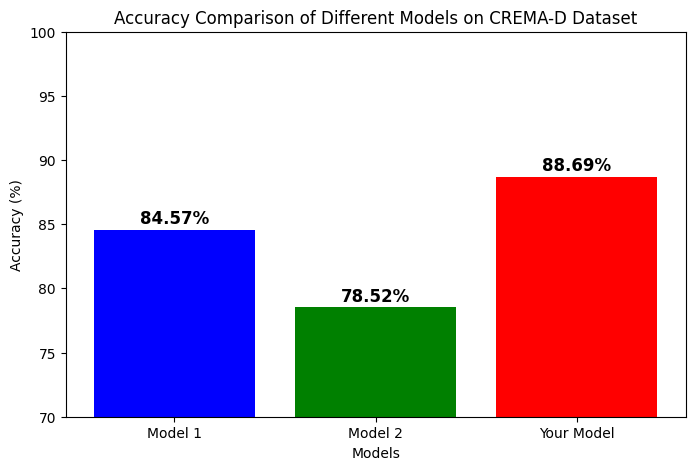

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = ['Model 1', 'Model 2', ' My Model']
# Accuracy values
accuracies = [84.57, 78.52, 88.69]

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])

# Add title and labels
plt.title('Accuracy Comparison of Different Models on CREMA-D Dataset')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 100)  # Set y-axis limits

# Annotate bars with accuracy values
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.5, f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Show the plot
plt.show()


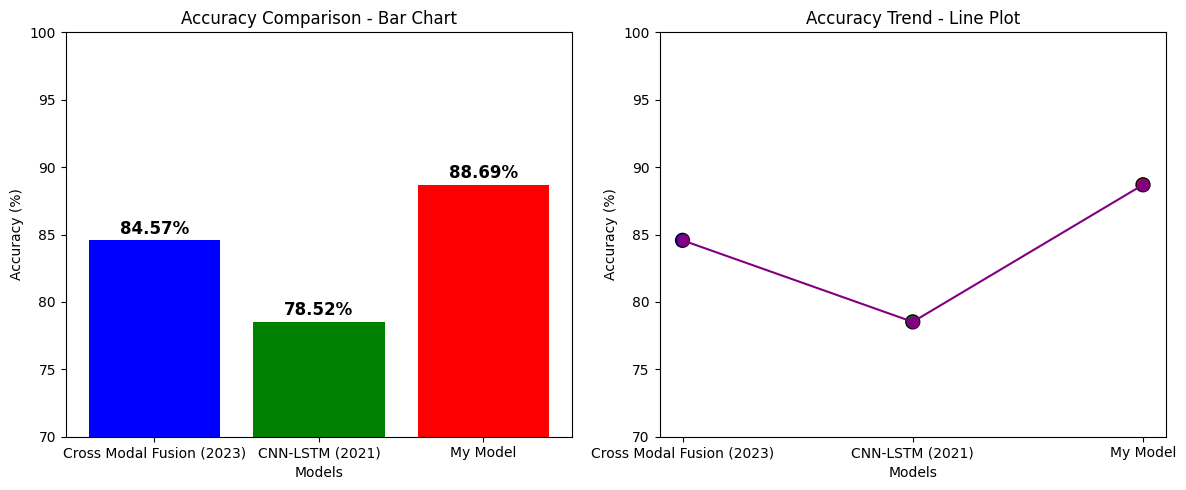

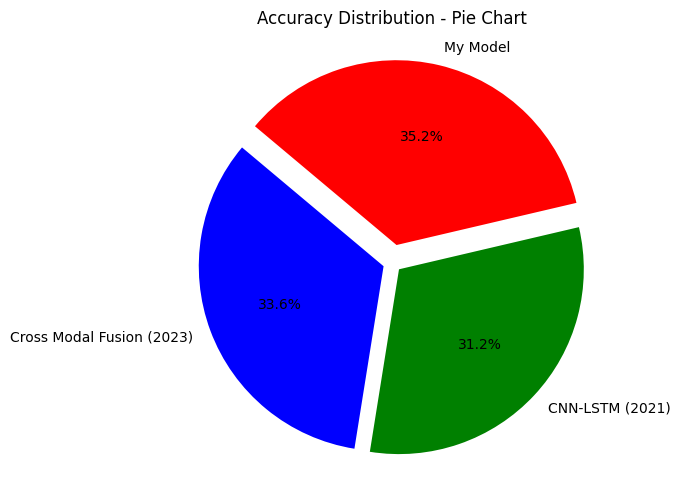

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Model names
models = ['Cross Modal Fusion (2023)', 'CNN-LSTM (2021)', 'My Model']
# Accuracy values
accuracies = [84.57, 78.52, 88.69]

# Set color palette
colors = ['blue', 'green', 'red']

# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(models, accuracies, color=colors)
axes[0].set_title('Accuracy Comparison - Bar Chart')
axes[0].set_xlabel('Models')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 100)

# Annotate bars with accuracy values
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.5, f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Line plot
axes[1].plot(models, accuracies, marker='o', linestyle='-', color='purple', markersize=8)
axes[1].set_title('Accuracy Trend - Line Plot')
axes[1].set_xlabel('Models')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(70, 100)

# Scatter plot overlay
axes[1].scatter(models, accuracies, color=colors, s=100, edgecolors='black')

# Show the plots
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(accuracies, labels=models, autopct='%1.1f%%', colors=colors, startangle=140, explode=[0.05, 0.05, 0.1])
plt.title('Accuracy Distribution - Pie Chart')
plt.show()


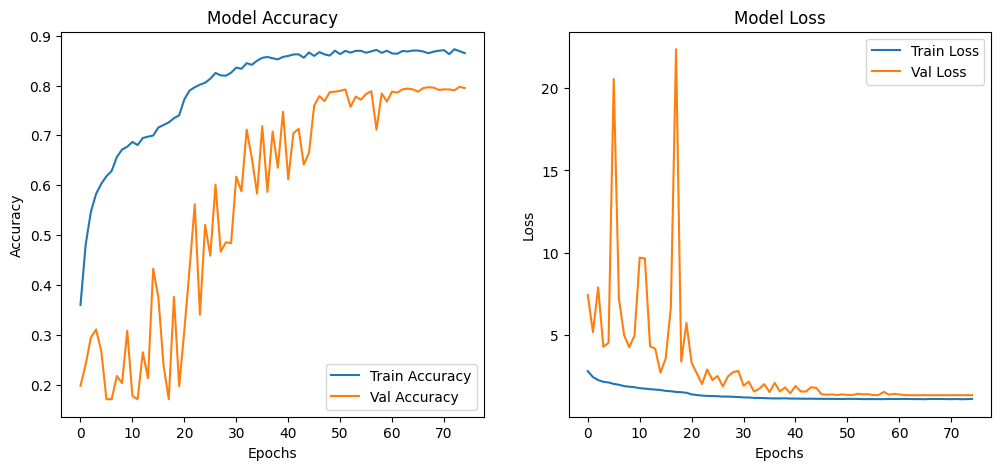

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


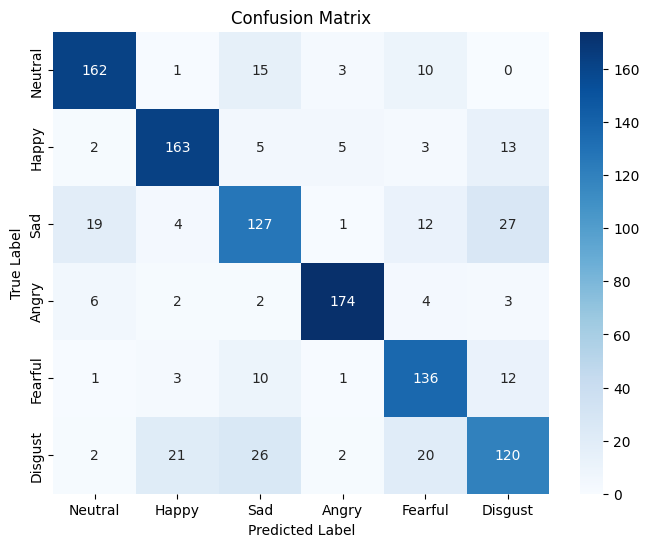

Classification Report:
               precision    recall  f1-score   support

     Neutral       0.84      0.85      0.85       191
       Happy       0.84      0.85      0.85       191
         Sad       0.69      0.67      0.68       190
       Angry       0.94      0.91      0.92       191
     Fearful       0.74      0.83      0.78       163
     Disgust       0.69      0.63      0.66       191

    accuracy                           0.79      1117
   macro avg       0.79      0.79      0.79      1117
weighted avg       0.79      0.79      0.79      1117



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Function to plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Plot loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.show()

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Function to display classification report
def show_classification_report(y_true, y_pred, class_names):
    report = classification_report(y_true, y_pred, target_names=class_names)
    print("Classification Report:\n", report)

# Example Usage
plot_training_history(history)

# Get predictions
y_pred = np.argmax(model.predict([X_test_audio, X_test_video]), axis=1)
plot_confusion_matrix(y_test, y_pred, class_names=['Neutral', 'Happy', 'Sad', 'Angry', 'Fearful', 'Disgust'])
show_classification_report(y_test, y_pred, class_names=['Neutral', 'Happy', 'Sad', 'Angry', 'Fearful', 'Disgust'])


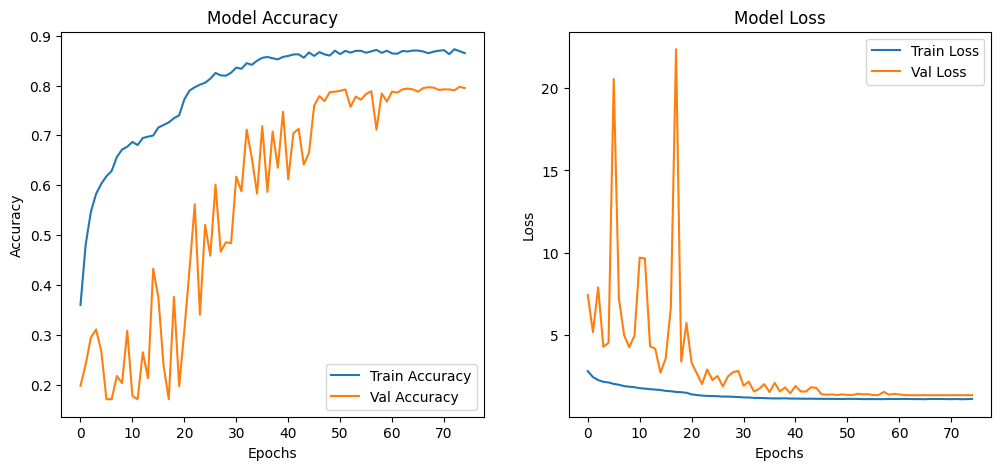

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


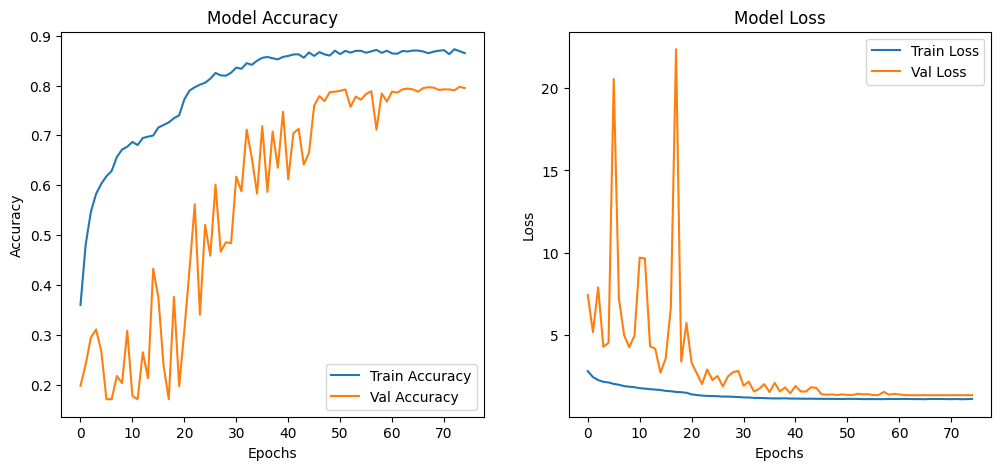

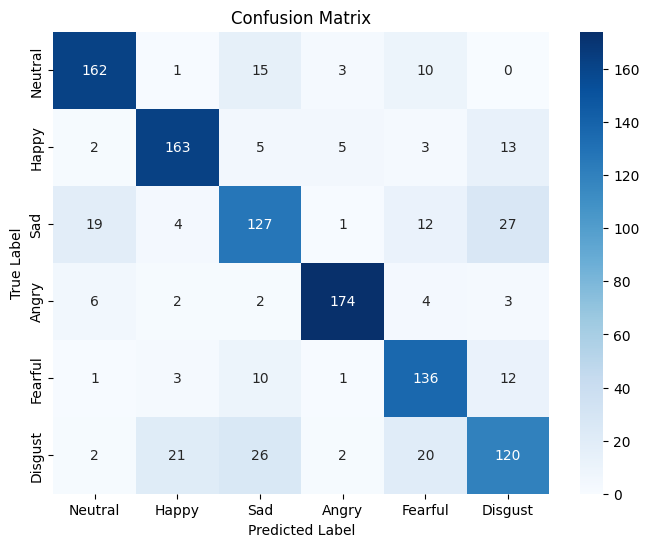

Classification Report:
              precision    recall  f1-score      support
Neutral        0.843750  0.848168  0.845953   191.000000
Happy          0.840206  0.853403  0.846753   191.000000
Sad            0.686486  0.668421  0.677333   190.000000
Angry          0.935484  0.910995  0.923077   191.000000
Fearful        0.735135  0.834356  0.781609   163.000000
Disgust        0.685714  0.628272  0.655738   191.000000
accuracy       0.789615  0.789615  0.789615     0.789615
macro avg      0.787796  0.790602  0.788411  1117.000000
weighted avg   0.789207  0.789615  0.788681  1117.000000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Function to plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Plot loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.show()

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Function to display classification report
def show_classification_report(y_true, y_pred, class_names):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print("Classification Report:")
    print(df_report)
    return df_report

# Function to display model performance summary
def display_model_summary(history, y_true, y_pred, class_names):
    plot_training_history(history)
    plot_confusion_matrix(y_true, y_pred, class_names)
    report_df = show_classification_report(y_true, y_pred, class_names)
    return report_df

# Example Usage
plot_training_history(history)

# Get predictions
y_pred = np.argmax(model.predict([X_test_audio, X_test_video]), axis=1)
report_df = display_model_summary(history, y_test, y_pred, class_names=['Neutral', 'Happy', 'Sad', 'Angry', 'Fearful', 'Disgust'])
